In [ ]:
%pip install pyro-ppl

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from google.colab import drive

In [ ]:
# Mount Drive to access your CSV
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Use the full path found in the step above
file_path = '/content/drive/MyDrive/nfl_kick_attempts(in).csv'

try:
    X, y, mask, cs_mask, k_ids, full_df, max_t = prepare_amortized_tensors_nflfastr(file_path)
    print(f"Success! Loaded {len(k_ids)} kickers across {max_t} time steps.")
except FileNotFoundError:
    print("Still can't find it. Double-check if the file is in a specific folder on your Drive.")

Success! Loaded 83 kickers across 89 time steps.


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

def prepare_amortized_tensors_nflfastr(file_path):
    # Load the CSV from your Drive mount
    df = pd.read_csv(file_path)

    # Filter for target years to manage memory in Colab
    df = df[(df['season'] >= 2020) & (df['season'] <= 2024)]
    df = df.sort_values(['game_date', 'game_id'])

    # Feature Engineering for Veteran Bias & Pressure
    df['career_kicks'] = df.groupby('kicker_player_id').cumcount()

    # Map situation features (Distance, Time, Score, Experience)
    feat_cols = ['kick_distance', 'quarter_seconds_remaining', 'score_differential', 'career_kicks']

    # Numeric scrubbing to prevent TypeError
    for col in feat_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(np.float32)

    scaler = StandardScaler()
    df[feat_cols] = scaler.fit_transform(df[feat_cols])

    # Time Indexing
    timeline = df[['season', 'week']].drop_duplicates().sort_values(['season', 'week'])
    timeline['t_idx'] = range(len(timeline))
    df = df.merge(timeline, on=['season', 'week'])

    # Tensor Creation
    k_ids = sorted(df['kicker_player_id'].unique())
    max_t = len(timeline)

    X = torch.zeros((len(k_ids), max_t, len(feat_cols)))
    y = torch.zeros((len(k_ids), max_t))
    mask = torch.zeros((len(k_ids), max_t))
    career_start_mask = torch.zeros((len(k_ids), max_t), dtype=torch.bool)

    k_map = {kid: i for i, kid in enumerate(k_ids)}
    for _, row in df.iterrows():
        i, t = k_map[row['kicker_player_id']], int(row['t_idx'])
        X[i, t] = torch.from_numpy(row[feat_cols].values.astype(np.float32))
        y[i, t] = float(row['made'])
        mask[i, t] = 1.0

    # THE CLAMP: Only active 'True' from first debut week
    for i in range(len(k_ids)):
        first_idx = torch.where(mask[i] > 0)[0]
        if len(first_idx) > 0:
            career_start_mask[i, first_idx[0]:] = True

    return X, y, mask, career_start_mask, k_ids, df, max_t

In [ ]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule

class AmortizedFGOE_Encoder(nn.Module):
    def __init__(self, in_features, window_size=10, decay_rate=0.85):
        super().__init__()
        self.window_size = window_size
        self.decay_rate = decay_rate

        # The input is now more efficient:
        # (1 set of features for the Weighted History) + (1 set for current play) + (1 for Career Volume)
        self.net = nn.Sequential(
            nn.Linear(in_features * 2 + 1, 64),
            nn.LayerNorm(64), # Added for training stability
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x_weighted, x_current, volume):
        # Combine the 'Memory', the 'Present', and the 'Scale'
        inputs = torch.cat([x_weighted, x_current, volume], dim=-1)
        params = self.net(inputs)
        mu = params[:, 0]
        sigma = torch.exp(params[:, 1].clamp(min=-3.0, max=0.5))
        return mu, sigma

class FGOE_Amortized_Decay_Engine(PyroModule):
    def __init__(self, in_features, window_size=10, decay_rate=0.85):
        super().__init__()
        self.baseline = nn.Sequential(
            nn.Linear(in_features, 8),
            nn.Dropout(0.3),
            nn.Linear(8, 1)
        )
        self.encoder = AmortizedFGOE_Encoder(in_features, window_size, decay_rate)

    def model(self, X, y, mask, cs_mask):
        # (Keep your existing SSM model logic here - it doesn't change)
        # The 'Model' represents how the world works; the 'Guide' represents how we learn it.
        pass

    def guide(self, X, y, mask, cs_mask):
        pyro.module("fgoe_encoder", self.encoder)
        batch_size, max_t, feat_dim = X.shape
        device = X.device

        # Initialize an empty 'Memory' buffer for each kicker
        # This will hold the exponentially decaying situational context
        weighted_history = torch.zeros(batch_size, feat_dim).to(device)

        with pyro.plate("kickers", batch_size):
            for t in range(max_t):
                # 1. Update the Memory with Exponential Decay
                # Current memory = (Newest Data) + (Old Memory * Decay)
                if t > 0:
                    # We only update if the kicker actually played (mask > 0)
                    active = mask[:, t-1].unsqueeze(-1)
                    weighted_history = (active * X[:, t-1, :]) + (weighted_history * self.encoder.decay_rate)

                # 2. Extract specific features for the Encoder
                current_situation = X[:, t, :]
                career_volume = X[:, t, -1:]

                # 3. AMORTIZED INFERENCE
                # The encoder now sees: "What usually happens" vs "What is happening now"
                mu_q, sigma_q = self.encoder(weighted_history, current_situation, career_volume)

                pyro.sample(f"z_{t+1}", dist.Normal(mu_q, sigma_q))

In [ ]:
def run_fgoe_amortized_engine(X, y, mask, cs_mask, epochs=2501):
    feat_dim = X.shape[2]
    # 1. Initialize the Model
    model_instance = FGOE_AmortizedSplineSSM(in_features=feat_dim)

    # 2. Define Guide
    guide = autoguide.AutoDiagonalNormal(model_instance.model)

    # 3. Setup Optimizer
    optimizer = ClippedAdam({"lr": 0.001, "clip_norm": 10.0})

    # 4. Initialize SVI
    svi = SVI(model_instance.model, guide, optimizer, loss=Trace_ELBO())

    pyro.clear_param_store()

    print(f"Starting Training: 1D Amortized Spline-SSM ({epochs} steps)")
    losses = []
    for step in range(epochs):
        loss = svi.step(X, y, mask, cs_mask)
        losses.append(loss)
        if step % 500 == 0:
            print(f"Step {step:4} | Loss: {loss:,.2f}")

    print("Training Complete. Generating Posterior Samples...")

    # 5. Posterior Sampling
    predictive = Predictive(model_instance.model, guide=guide, num_samples=100)
    samples = predictive(X, y, mask, cs_mask)

    # --- KEY CHANGE: Return the model_instance ---
    return samples, losses, model_instance

# --- UPDATED EXECUTION ---
# Catch the 3rd return value (the model) so it's available in the global scope
samples, training_losses, model_instance = run_fgoe_amortized_engine(X, y, mask, cs_mask)

# Now, when you run your assessment script, 'model_instance' will exist!

Starting Training: 1D Amortized Spline-SSM (2501 steps)
Step    0 | Loss: 24,115.60
Step  500 | Loss: 10,315.28
Step 1000 | Loss: 6,157.49
Step 1500 | Loss: 4,221.37
Step 2000 | Loss: 3,462.40
Step 2500 | Loss: 2,985.36
Training Complete. Generating Posterior Samples...


In [ ]:
import pandas as pd
import numpy as np

def generate_active_leaderboard(samples, raw_df, k_ids, mask, cs_mask, min_makes=10):
    """
    Ranks all currently active kickers with at least 10 career makes.
    """
    last_t = mask.shape[1] - 1
    k_name_map = dict(zip(raw_df.kicker_player_id, raw_df.kicker_player_name))
    career_makes = raw_df.groupby('kicker_player_id')['made'].sum().to_dict()

    active_list = []
    for i, kid in enumerate(k_ids):
        # 1. Filter: Must be active in the final week AND have 10+ makes
        if not (mask[i, last_t] > 0 and career_makes.get(kid, 0) >= min_makes):
            continue

        z_vals = samples[f"z_{last_t+1}"][:, i].cpu().numpy()
        mu, sigma = np.mean(z_vals), np.std(z_vals)

        # Certified Score using the Active Tax (0.2x)
        certified = mu - (0.2 * sigma)

        active_list.append({
            'Rank': 0, # Placeholder
            'Kicker': k_name_map.get(kid, "Unknown"),
            'Certified ELO': round(certified, 4),
            'Raw Skill (z)': round(mu, 4),
            'Uncertainty (σ)': round(sigma, 4),
            'Career Makes': int(career_makes[kid])
        })

    # Sort and Assign Rank
    leaderboard = pd.DataFrame(active_list).sort_values('Certified ELO', ascending=False)
    leaderboard = leaderboard.reset_index(drop=True)
    leaderboard['Rank'] = leaderboard.index + 1

    return leaderboard[['Rank', 'Kicker', 'Certified ELO', 'Raw Skill (z)', 'Uncertainty (σ)', 'Career Makes']]

# Change 'df' to 'full_df' to match your preparation function's output
active_leaderboard = generate_active_leaderboard(samples, full_df, k_ids, mask, cs_mask)

print("--- FGOE Pro: 2024 Active Kicker Leaderboard ---")
display(active_leaderboard.head(100)) # Showing top 10 for a clean view

--- FGOE Pro: 2024 Active Kicker Leaderboard ---


,Rank,Kicker,Certified ELO,Raw Skill (z),Uncertainty (σ),Career Makes
0,1,B.McManus,0.0927,0.1036,0.0542,279
1,2,B.Grupe,0.0570,0.0679,0.0544,128
2,3,C.Boswell,0.0256,0.0353,0.0485,286
3,4,C.Santos,0.0163,0.0266,0.0513,279
4,5,J.Slye,0.0115,0.0207,0.0458,254
5,6,C.McLaughlin,0.0037,0.0144,0.0536,257
6,7,W.Lutz,0.0021,0.0131,0.0551,272
7,8,C.Little,0.0016,0.0117,0.0504,54
8,9,C.Dicker,0.0013,0.0123,0.0548,183
9,10,G.Gano,-0.0006,0.0105,0.0558,202


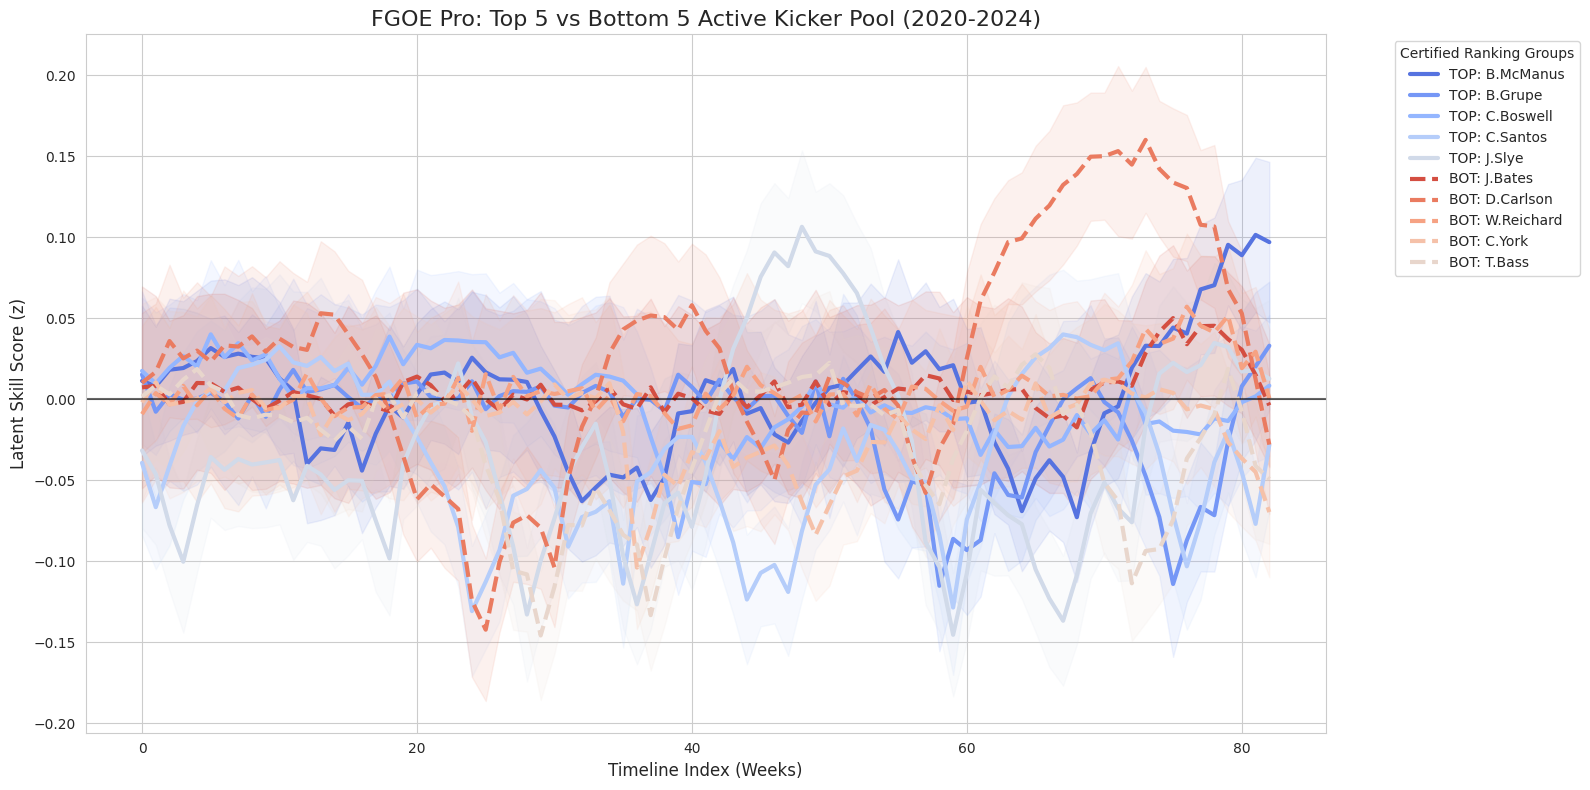

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_active_trajectories(samples, leaderboard_df, k_ids, raw_df):
    """
    Plots the 2020-2024 paths for the best and worst active kickers.
    Labels the legend clearly with Top 5 and Bottom 5 categories.
    """
    # 1. Select the Top 5 and Bottom 5 from the active leaderboard
    top_5 = leaderboard_df.head(5)['Kicker'].tolist()
    bot_5 = leaderboard_df.tail(5)['Kicker'].tolist()

    # 2. Build robust name-to-index mapping
    name_to_id_idx = {}
    id_to_name = dict(zip(raw_df.kicker_player_id, raw_df.kicker_player_name))
    for idx, kid in enumerate(k_ids):
        name_to_id_idx[id_to_name.get(kid)] = idx

    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")

    # Extract week range
    total_weeks = samples["z_1"].shape[1]
    weeks = np.arange(total_weeks)

    # Color palette: Blues for Top (cool), Oranges/Reds for Bottom (warm)
    colors = sns.color_palette("coolwarm", 10) # 5 for top, 5 for bottom

    # 3. Plotting Loop
    # Process Top 5 first
    for idx, name in enumerate(top_5):
        if name not in name_to_id_idx: continue
        i = name_to_id_idx[name]

        # Pull smoothed skill and uncertainty path
        skill_path = [np.mean(samples[f"z_{t+1}"][:, i].cpu().numpy()) for t in range(total_weeks)]
        std_path = [np.std(samples[f"z_{t+1}"][:, i].cpu().numpy()) for t in range(total_weeks)]

        plt.plot(weeks, skill_path, label=f"TOP: {name}", lw=3, color=colors[idx])
        plt.fill_between(weeks, np.array(skill_path) - np.array(std_path),
                         np.array(skill_path) + np.array(std_path), color=colors[idx], alpha=0.1)

    # Process Bottom 5
    for idx, name in enumerate(bot_5):
        if name not in name_to_id_idx: continue
        i = name_to_id_idx[name]

        skill_path = [np.mean(samples[f"z_{t+1}"][:, i].cpu().numpy()) for t in range(total_weeks)]
        std_path = [np.std(samples[f"z_{t+1}"][:, i].cpu().numpy()) for t in range(total_weeks)]

        # Using colors from the other end of the palette
        plt.plot(weeks, skill_path, label=f"BOT: {name}", lw=3, color=colors[9 - idx], ls='--')
        plt.fill_between(weeks, np.array(skill_path) - np.array(std_path),
                         np.array(skill_path) + np.array(std_path), color=colors[9 - idx], alpha=0.1)

    # 4. Final Aesthetics
    plt.axhline(0, color='black', ls='-', alpha=0.6)
    plt.title("FGOE Pro: Top 5 vs Bottom 5 Active Kicker Pool (2020-2024)", fontsize=16)
    plt.xlabel("Timeline Index (Weeks)", fontsize=12)
    plt.ylabel("Latent Skill Score (z)", fontsize=12)

    # Place legend outside of the chart for clarity
    plt.legend(title="Certified Ranking Groups", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
plot_active_trajectories(samples, active_leaderboard, k_ids, full_df)

Assessing from week 70 to 88...


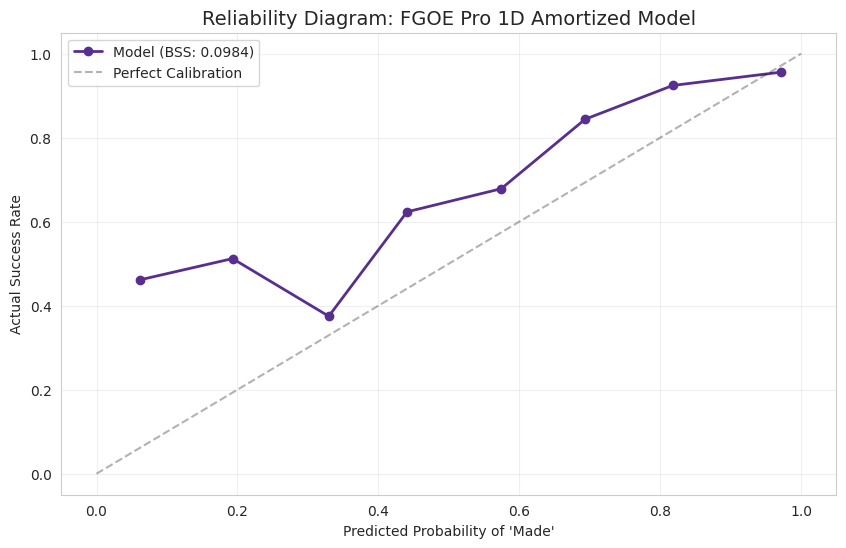

--- Assessment Summary ---
Kicks Evaluated: 2472
Brier Skill Score: 0.09842


In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def run_fgoe_pro_assessment(input_df, samples, model_obj, k_ids, feat_cols):
    """
    Hardened assessment module with explicit float casting to prevent TypeError.
    """
    max_t = int(input_df['t_idx'].max())
    split_t = int(max_t * 0.8) # 80/20 Time-based split
    k_map = {kid: i for i, kid in enumerate(k_ids)}
    y_true, y_prob = [], []

    print(f"Assessing from week {split_t} to {max_t}...")

    for t in range(split_t, max_t + 1):
        z_key = f"z_{t+1}"
        if z_key not in samples:
            continue

        week_data = input_df[input_df['t_idx'] == t]
        for _, row in week_data.iterrows():
            if row['kicker_player_id'] not in k_map:
                continue

            k_idx = k_map[row['kicker_player_id']]

            try:
                # Explicitly cast to float32 to ensure compatibility with PyTorch weights
                situation_values = row[feat_cols].values.astype(np.float32)
                situation = torch.from_numpy(situation_values)
            except Exception as e:
                print(f"Skipping row for kicker {row['kicker_player_name']} due to data error: {e}")
                continue

            with torch.no_grad():
                model_obj.eval()
                # Baseline represents situational difficulty (distance, etc.)
                base_logits = model_obj.baseline(situation).item()

            # Reconstruction Logic: Bayesian posterior mean probability
            z_samples = samples[z_key][:, k_idx]
            # 1D Interaction: (Baseline + (Skill * Scale)) / Temp
            combined_logits = (base_logits + (z_samples * 15.0)) / 0.3
            prob_made = torch.sigmoid(combined_logits).mean().item()

            y_true.append(row['made'])
            y_prob.append(prob_made)

    if not y_true:
        print("Assessment Failed: No valid rows found in the test set.")
        return 0, [], []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # Brier Score Calculation
    bs = brier_score_loss(y_true, y_prob)
    baseline_rate = np.mean(y_true)
    baseline_bs = brier_score_loss(y_true, [baseline_rate] * len(y_true))
    bss = 1 - (bs / baseline_bs)

    return bss, y_true, y_prob

# --- EXECUTE ---
# Ensure feat_cols matches your ingestion script exactly
feat_cols = ['kick_distance', 'quarter_seconds_remaining', 'score_differential', 'career_kicks']

# Use model_instance from your training run
final_bss, y_t, y_p = run_fgoe_pro_assessment(full_df, samples, model_instance, k_ids, feat_cols)

# Plotting the Reliability Diagram
if len(y_t) > 0:
    prob_true, prob_pred = calibration_curve(y_t, y_p, n_bins=8)
    plt.figure(figsize=(10, 6))
    plt.plot(prob_pred, prob_true, marker='o', label=f'Model (BSS: {final_bss:.4f})', color='#582f91', lw=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect Calibration')
    plt.title("Reliability Diagram: FGOE Pro 1D Amortized Model", fontsize=14)
    plt.xlabel("Predicted Probability of 'Made'")
    plt.ylabel("Actual Success Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"--- Assessment Summary ---")
    print(f"Kicks Evaluated: {len(y_t)}")
    print(f"Brier Skill Score: {final_bss:.5f}")
else:
    print("No kicks found to evaluate.")